## Objetivo e preparação

Este tutorial compara a regra dos trapézios composta à integral exata de $e^{-x}$.
Pressupõe noções de Python e integração numérica. Ao final, será possível verificar
experimentalmente a ordem de convergência, sem confundi-la com uma prova matemática.

Para reexecutar: Python 3, NumPy, pandas, Matplotlib e IPython. Execute as células
em ordem e salve o arquivo com os resultados antes de construir o site.

1. Calcular a aproximação e o erro.
2. Inspecionar a tabela e o gráfico.
3. Repetir a análise com outro integrando.

\begin{equation}
I = \int_0^1 e^{-x}\,\mathrm{d}x = 1-e^{-1}.\label{eq:notebook-integral}
\end{equation}

O erro é medido em relação a $\eqref{eq:notebook-integral}$, sem ajuste aos resultados.

In [1]:
from math import exp, log2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, SVG, HTML
from io import StringIO

exact = 1 - exp(-1)
rows = []
previous_error = None
for n in [8, 16, 32, 64, 128]:
    x = np.linspace(0, 1, n + 1)
    approximation = np.trapezoid(np.exp(-x), x)
    error = abs(approximation - exact)
    order = log2(previous_error / error) if previous_error else np.nan
    rows.append({"n": n, "h": 1/n, "erro absoluto": error, "ordem": order})
    previous_error = error
results = pd.DataFrame(rows)
print(f"Integral exata: {exact:.10f}")

Integral exata: 0.6321205588


## Tabela de convergência

A ordem estimada se aproxima de 2 quando a malha é refinada. A primeira linha
não tem uma estimativa, pois ainda não há dois erros para comparar.

In [2]:
display(HTML(results.to_html(index=False, formatters={"h": "{:.5f}".format, "erro absoluto": "{:.5e}".format, "ordem": "{:.4f}".format}, na_rep="—")))

n,h,erro absoluto,ordem
8,0.12500,8.22859e-04,—
16,0.06250,2.05755e-04,1.9997
32,0.03125,5.14413e-05,1.9999
64,0.01562,1.28605e-05,2.0000
128,0.00781,3.21513e-06,2.0000


## Gráfico

O declive no gráfico logarítmico pode ser comparado com a referência $h^2$.
O gráfico a seguir é salvo como SVG no notebook, preservando as curvas e legendas.

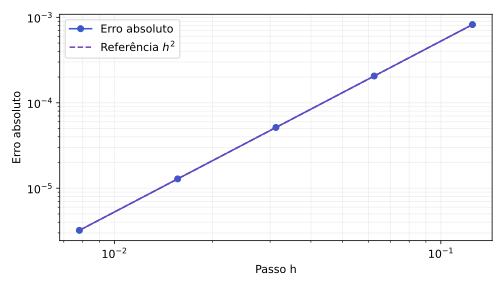

In [3]:
plt.rcParams.update({"font.size": 11, "figure.dpi": 120})
fig, ax = plt.subplots(figsize=(7, 4))
h = results["h"].to_numpy()
errors = results["erro absoluto"].to_numpy()
ax.loglog(h, errors, "o-", color="#3859C8", label="Erro absoluto")
ax.loglog(h, errors[0] * (h / h[0])**2, "--", color="#7542BC", label=r"Referência $h^2$")
ax.set(xlabel="Passo h", ylabel="Erro absoluto")
ax.grid(True, which="both", alpha=0.2)
ax.legend()
fig.tight_layout()
buffer = StringIO()
fig.savefig(buffer, format="svg", facecolor="white")
plt.close(fig)
display(SVG(buffer.getvalue()))

## Interpretação e exercício

Neste integrando suave, a razão entre erros sucessivos se aproxima de 4. Como o
passo é dividido por 2, isso corresponde à ordem observada 2.

::: warning title="Limite desta verificação"
Não extrapole essa ordem para integrandos singulares. Primeiro verifique as
hipóteses do método e use refinamentos suficientes para separar erro de truncamento
e arredondamento.
:::

**Exercício:** repita o teste para $f(x)=x^2$, cuja integral em $[0,1]$ é $1/3$.
A célula abaixo fornece um ponto de partida e verifica um resultado conhecido.

In [4]:
n = 16
x = np.linspace(0, 1, n + 1)
error = abs(np.trapezoid(x**2, x) - 1/3)
expected_error = 1 / (6 * n**2)
assert np.isclose(error, expected_error)
print(f"Erro para x² com n={n}: {error:.8f}")

Erro para x² com n=16: 0.00065104
